Dataset Shape: (1000, 6)
   Login_Frequency  Time_Spent_Hours  Support_Tickets  Monthly_Usage  \
0                7          3.342606                1      61.000212   
1               20          2.500086                2      84.512289   
2               29          1.159991                4      56.739190   
3               15          4.856463                3      24.156526   
4               11          7.489095                1      82.902256   

   Subscription_Length  Renewed  
0                   20        0  
1                   19        0  
2                   20        0  
3                   35        0  
4                    2        0  

Missing Values
Login_Frequency        0
Time_Spent_Hours       0
Support_Tickets        0
Monthly_Usage          0
Subscription_Length    0
Renewed                0
dtype: int64


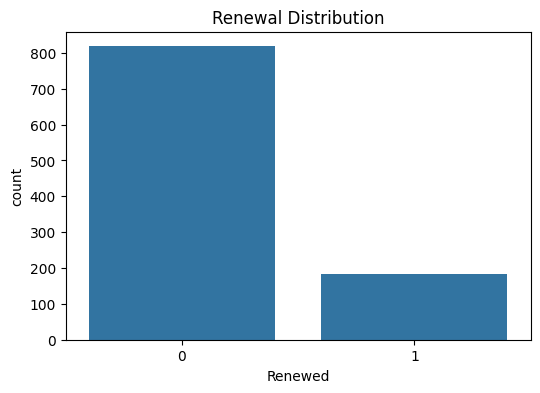

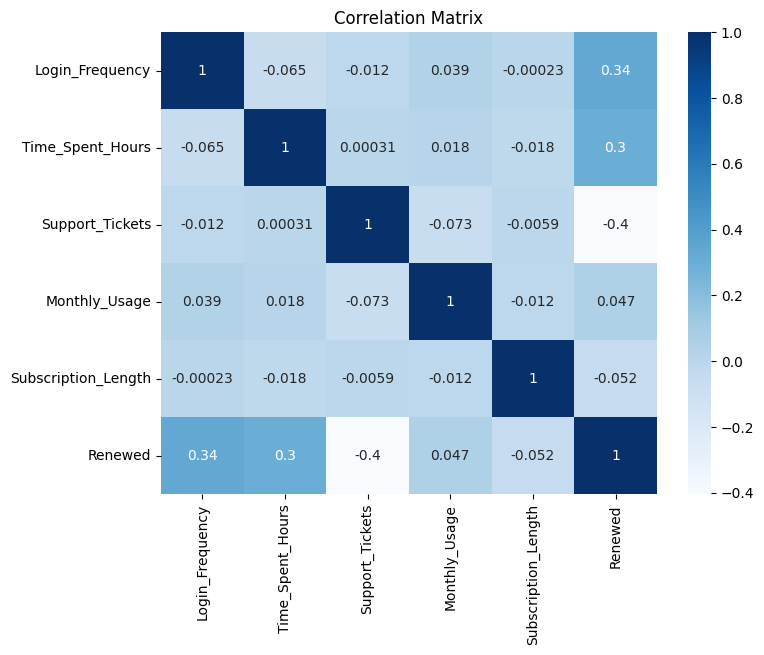


Accuracy : 90.0 %

ROC AUC Score : 0.944

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       167
           1       0.74      0.61      0.67        33

    accuracy                           0.90       200
   macro avg       0.83      0.78      0.80       200
weighted avg       0.89      0.90      0.90       200



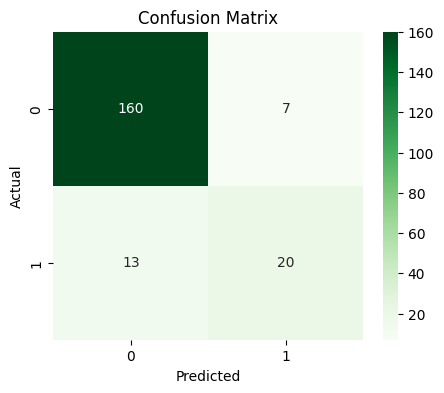

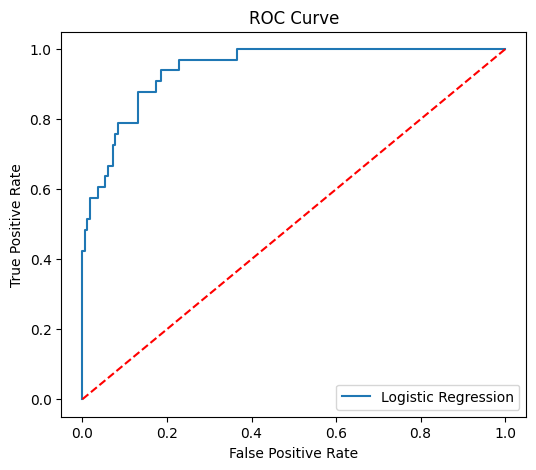


Feature Importance
               Feature  Coefficient
0      Login_Frequency     1.958155
1     Time_Spent_Hours     1.729119
3        Monthly_Usage     0.005280
4  Subscription_Length    -0.131713
2      Support_Tickets    -2.190360


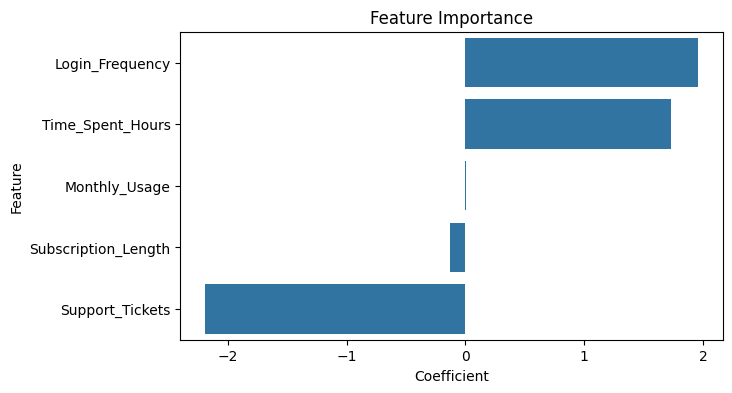


========== Prediction ==========
Renewal Prediction : 0
Renewal Probability : 25.14 %
Customer is likely to CHURN.


In [1]:
# ==========================================================
# Predictive Churn Analysis
# Logistic Regression
# Google Colab Project
# ==========================================================

# Install libraries (if needed)
!pip -q install seaborn

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ----------------------------------------------------------
# STEP 1 : Generate Sample Customer Dataset
# ----------------------------------------------------------

np.random.seed(42)

n = 1000

data = pd.DataFrame({

    "Login_Frequency" : np.random.randint(1,30,n),

    "Time_Spent_Hours" : np.random.uniform(1,12,n),

    "Support_Tickets" : np.random.randint(0,8,n),

    "Monthly_Usage" : np.random.uniform(20,100,n),

    "Subscription_Length" : np.random.randint(1,36,n)

})

# Target Variable
data["Renewed"] = (
    (data["Login_Frequency"] > 12) &
    (data["Time_Spent_Hours"] > 5) &
    (data["Support_Tickets"] < 4)
).astype(int)

print("Dataset Shape:",data.shape)

print(data.head())

# ----------------------------------------------------------
# STEP 2 : Data Cleaning
# ----------------------------------------------------------

print("\nMissing Values")
print(data.isnull().sum())

# Remove duplicates
data = data.drop_duplicates()

# ----------------------------------------------------------
# STEP 3 : Exploratory Data Analysis
# ----------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="Renewed",data=data)
plt.title("Renewal Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot=True,cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# ----------------------------------------------------------
# STEP 4 : Feature Selection
# ----------------------------------------------------------

X = data.drop("Renewed",axis=1)

y = data["Renewed"]

# ----------------------------------------------------------
# STEP 5 : Train-Test Split
# ----------------------------------------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------------------------------------
# STEP 6 : Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------------------------------
# STEP 7 : Logistic Regression Model
# ----------------------------------------------------------

model = LogisticRegression()

model.fit(X_train,y_train)

# ----------------------------------------------------------
# STEP 8 : Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# ----------------------------------------------------------
# STEP 9 : Model Evaluation
# ----------------------------------------------------------

accuracy = accuracy_score(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

print("\nAccuracy :",round(accuracy*100,2),"%")

print("\nROC AUC Score :",round(auc,3))

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

# ----------------------------------------------------------
# STEP 10 : Confusion Matrix
# ----------------------------------------------------------

plt.figure(figsize=(5,4))

sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ----------------------------------------------------------
# STEP 11 : ROC Curve
# ----------------------------------------------------------

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Logistic Regression")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ----------------------------------------------------------
# STEP 12 : Feature Importance
# ----------------------------------------------------------

importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

importance = importance.sort_values(by="Coefficient",ascending=False)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(7,4))

sns.barplot(data=importance,
            x="Coefficient",
            y="Feature")

plt.title("Feature Importance")

plt.show()

# ----------------------------------------------------------
# STEP 13 : Predict Renewal Probability for New Customers
# ----------------------------------------------------------

new_customer = pd.DataFrame({

    "Login_Frequency":[18],

    "Time_Spent_Hours":[7],

    "Support_Tickets":[2],

    "Monthly_Usage":[75],

    "Subscription_Length":[18]

})

scaled = scaler.transform(new_customer)

prediction = model.predict(scaled)[0]

probability = model.predict_proba(scaled)[0][1]

print("\n========== Prediction ==========")

print("Renewal Prediction :",prediction)

print("Renewal Probability :",round(probability*100,2),"%")

if prediction==1:
    print("Customer is likely to RENEW subscription.")
else:
    print("Customer is likely to CHURN.")

# ----------------------------------------------------------
# END
# ----------------------------------------------------------